# Практика: DBSCAN — плотностная кластеризация

## Что вы сделаете
В этом ноутбуке вы:

1. исследуете нелинейные 2D-датасеты и убедитесь в ограничениях K-Means;
2. построите **k-distance plot** и выберете оптимальный параметр `eps`;
3. применените **DBSCAN** и проанализируете результаты;
4. сравните DBSCAN с K-Means на нелинейных данных;
5. исследуете влияние гиперпараметров `eps` и `min_samples`;
6. применените DBSCAN к реальному датасету **Wine** и проанализируете шумовые точки;
7. сравните силуэт DBSCAN и K-Means, сделаете выводы.

## Важно
- Заполняйте все ячейки с пометкой `# YOUR CODE HERE`.
- Не удаляйте проверки: они подскажут, правильно ли вы идёте.
- Вопросы для размышления помогут вам глубже понять алгоритм.

## Датасеты
- **`make_moons`** и **`make_circles`** из `sklearn.datasets`: 2D-данные с нелинейными кластерами.
- **Wine** (`load_wine`): реальный многомерный датасет (13 признаков, 3 класса).

## Что сдавать
1. Заполненный ноутбук со всеми графиками.
2. Краткие выводы в конце каждого раздела.
3. Итоговый вывод: когда DBSCAN лучше K-Means и когда нет.

---
## Шаг 1. Импорты и настройки

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_moons, make_circles, load_wine
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Импорты выполнены успешно!")

Импорты выполнены успешно!


---
## Шаг 2. Исследование нелинейных датасетов

Сгенерируем два датасета, с которыми K-Means заведомо не справится.

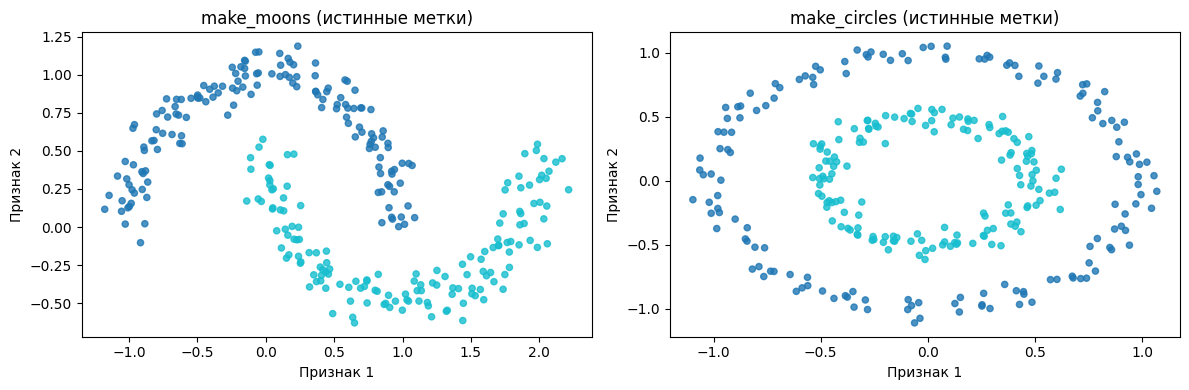

In [2]:
# Генерация датасетов
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05,
                                     factor=0.5, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=y_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("make_moons (истинные метки)")
axes[0].set_xlabel("Признак 1")
axes[0].set_ylabel("Признак 2")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=y_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("make_circles (истинные метки)")
axes[1].set_xlabel("Признак 1")
axes[1].set_ylabel("Признак 2")

plt.tight_layout()
plt.show()

  File "C:\Users\vensv\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\vensv\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\vensv\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                

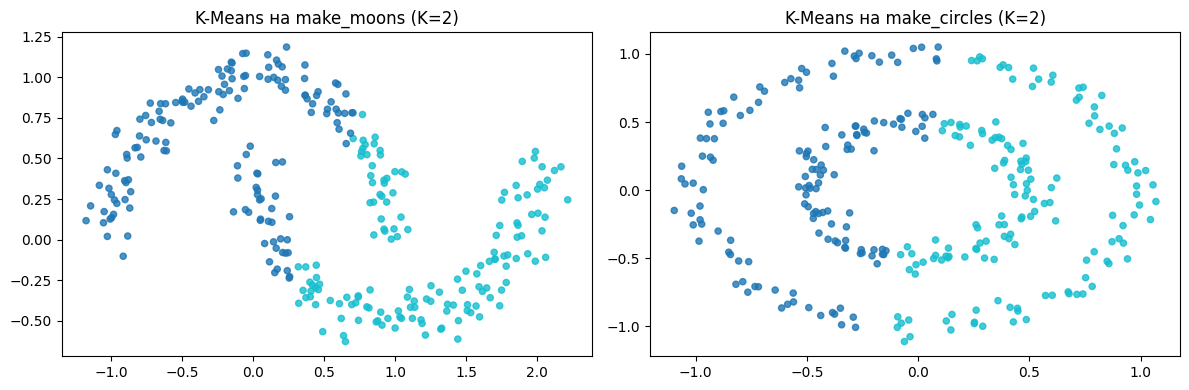

In [3]:
# Применим K-Means к этим датасетам
# YOUR CODE HERE
# 1. Создайте KMeans с n_clusters=2, random_state=RANDOM_STATE
# 2. Обучите на X_moons и X_circles
# 3. Получите метки кластеров

kmeans_moons = KMeans(n_clusters=2, random_state=RANDOM_STATE)
kmeans_moons.fit(X_moons)
labels_km_moons = kmeans_moons.labels_

kmeans_circles = KMeans(n_clusters=2, random_state=RANDOM_STATE)
kmeans_circles.fit(X_circles)
labels_km_circles = kmeans_circles.labels_

# Визуализация результатов K-Means
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=labels_km_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("K-Means на make_moons (K=2)")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=labels_km_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("K-Means на make_circles (K=2)")

plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** Почему K-Means не может правильно разделить «луны» и «кольца»? Связано ли это с формой функционала ошибки?

Потому что таковы ограничения математики к-средних. Алгоритм ищет выпуклые шарообразные формы, так достигается стабильность расположения центроидов. 

В случае лун центроид каждого полукольца оказывается в центре его кривизны, но тогда к нему по расстоянию будет ближе часть точек противоположного полукольца. В случае колец центроиды обоих кластеров вовсе совпадают в одной точке — центре эллипсов.

---
## Шаг 3. k-Distance Plot и выбор eps

Построим k-distance plot для датасета `make_moons`. Используем k = 5 (= `min_samples`).

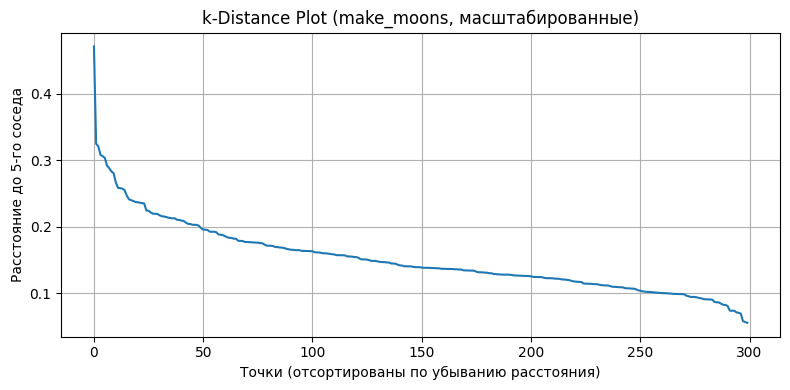

Найдите 'локоть' на графике и запишите подходящее значение eps:


In [4]:
# Масштабируем данные
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

# 1. Создайте NearestNeighbors(n_neighbors=k) и обучите на X_moons_scaled
# 2. Вызовите .kneighbors() для получения матрицы расстояний
# 3. Возьмите расстояние до k-го соседа (последний столбец distances)
# 4. Отсортируйте по убыванию

k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_moons_scaled)
distances, _ = nbrs.kneighbors(X_moons_scaled)
k_distances_moons = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances_moons)
plt.xlabel("Точки (отсортированы по убыванию расстояния)")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.title("k-Distance Plot (make_moons, масштабированные)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Найдите 'локоть' на графике и запишите подходящее значение eps:")

**❓ Вопрос для размышления:** Где находится «локоть»? Как он указывает на границу между точками кластеров и шумом?

$\epsilon = 0.25$ Локоть указывает где внутрикластерные расстояния переходят в границу между разными кластерами.

---
## Шаг 4. DBSCAN на нелинейных датасетах

Применим DBSCAN к `make_moons` и `make_circles`. Обратите внимание на масштабирование.

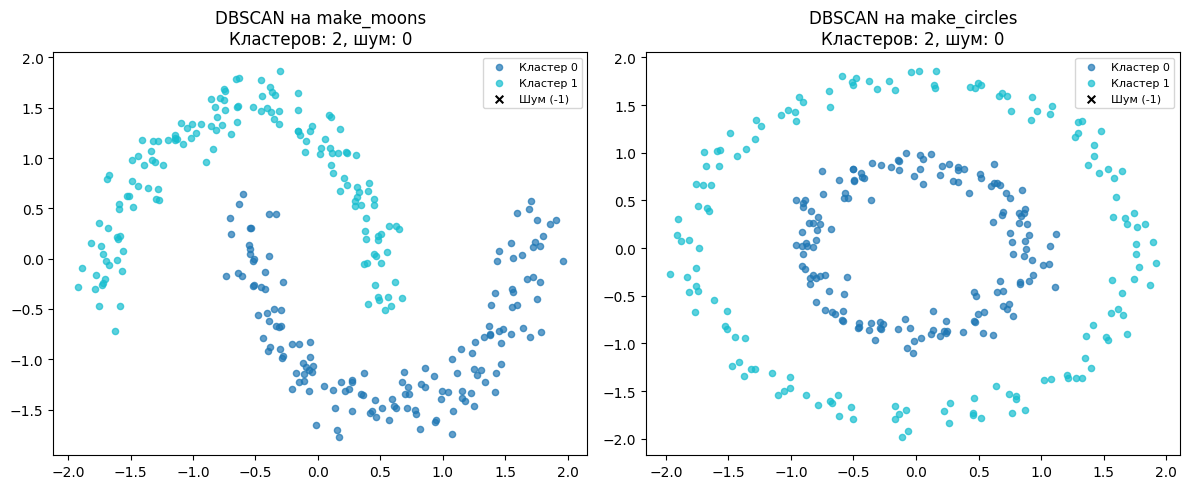

In [5]:
# Масштабируем make_circles
scaler_circles = StandardScaler()
X_circles_scaled = scaler_circles.fit_transform(X_circles)

# YOUR CODE HERE
# 1. Создайте DBSCAN с подобранным eps (из k-distance plot) и min_samples=5
# 2. Примените fit_predict к X_moons_scaled и X_circles_scaled
# 3. Подберите параметры так, чтобы алгоритм нашёл 2 кластера


db_moons = DBSCAN(eps = 0.32, min_samples=5)   # замените
labels_db_moons = db_moons.fit_predict(X_circles_scaled)

db_circles = DBSCAN(eps = 0.32, min_samples=5)
labels_db_circles = db_circles.fit_predict(X_circles_scaled)

# Вспомогательная функция для визуализации
def plot_dbscan_results(X, labels, title, ax):
    """Визуализирует результаты DBSCAN.
    Корневые точки — крупные, граничные — обычные, шум — крестики."""
    noise_mask = labels == -1
    colors = cm.tab10(np.linspace(0, 1, max(labels)+1)) if max(labels) >= 0 else []
    
    for i in range(max(labels)+1):
        mask = labels == i
        ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7,
                   color=colors[i], label=f'Кластер {i}')
    
    ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
               s=30, c='black', marker='x', label='Шум (-1)')
    
    n_cl = max(labels) + 1 if max(labels) >= 0 else 0
    n_noise = noise_mask.sum()
    ax.set_title(f"{title}\nКластеров: {n_cl}, шум: {n_noise}")
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_dbscan_results(X_moons_scaled, labels_db_moons, "DBSCAN на make_moons", axes[0])
plot_dbscan_results(X_circles_scaled, labels_db_circles, "DBSCAN на make_circles", axes[1])
plt.tight_layout()
plt.show()

---
## Шаг 5. Сравнение DBSCAN и K-Means на нелинейных данных

In [6]:
# Сравнение силуэта DBSCAN vs K-Means для make_moons

# YOUR CODE HERE
# 1. Обучите KMeans(n_clusters=2) на X_moons_scaled
# 2. Вычислите silhouette_score для K-Means
# 3. Вычислите silhouette_score для DBSCAN (только для некластерных точек!)
#    Подсказка: исключите точки с labels == -1

kmeans_moons_scaled = KMeans(n_clusters=2, random_state=RANDOM_STATE)
kmeans_moons_scaled = kmeans_moons_scaled.fit(X_moons_scaled)
labels_km_moons = kmeans_moons_scaled.labels_


score_kmeans = silhouette_score(X_moons_scaled, labels_km_moons)
score_dbscan = silhouette_score(X_moons_scaled, labels_db_moons)

print("=== Коэффициент силуэта на make_moons ===")
print(f"K-Means (K=2): {score_kmeans:.3f}" if score_kmeans is not None else "K-Means: не вычислен")
print(f"DBSCAN:        {score_dbscan:.3f}" if score_dbscan is not None else "DBSCAN: не вычислен")

=== Коэффициент силуэта на make_moons ===
K-Means (K=2): 0.494
DBSCAN:        0.380


**❓ Вопрос для размышления:** Какой алгоритм получил лучший силуэт? Соответствует ли это визуальному впечатлению? Можно ли всегда доверять силуэту как абсолютной мере качества?

---
## Шаг 6. Исследование влияния гиперпараметров

Посмотрим, как меняется результат DBSCAN при разных значениях `eps` и `min_samples`.

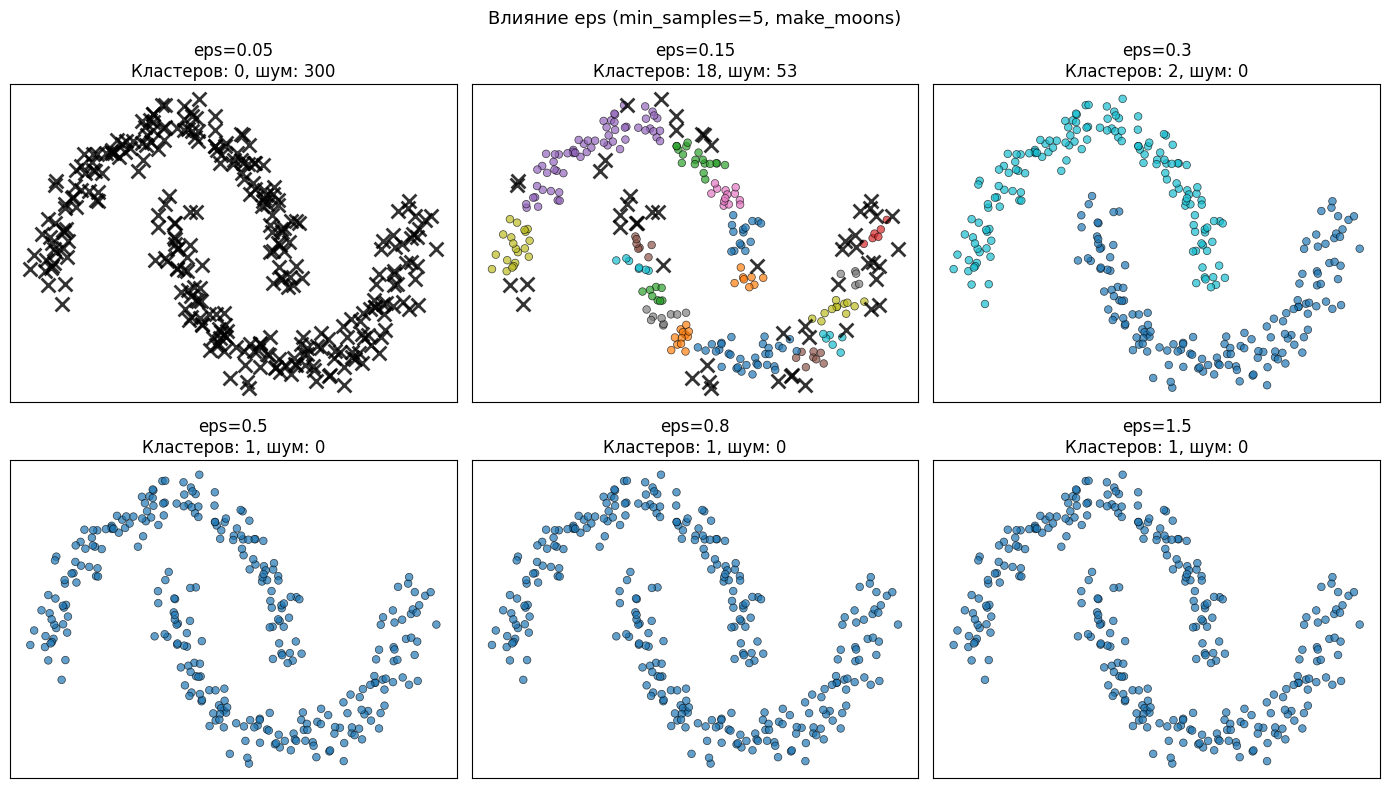

In [7]:
# Сетка eps при фиксированном min_samples=5
eps_values = [0.05, 0.15, 0.3, 0.5, 0.8, 1.5]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, eps_val in enumerate(eps_values):
    db = DBSCAN(eps=eps_val, min_samples=5)
    labels_i = db.fit_predict(X_moons_scaled)
    
    n_cl = len(set(labels_i)) - (1 if -1 in labels_i else 0)
    n_noise = (labels_i == -1).sum()
    
    # Основные точки
    mask_clustered = labels_i != -1
    axes[i].scatter(X_moons_scaled[mask_clustered, 0], 
                    X_moons_scaled[mask_clustered, 1],
                    c=labels_i[mask_clustered], cmap='tab10', 
                    s=30, alpha=0.7, edgecolors='k', linewidth=0.5)
    
    # Шумовые точки — чёрные крестики
    mask_noise = labels_i == -1
    axes[i].scatter(X_moons_scaled[mask_noise, 0], 
                    X_moons_scaled[mask_noise, 1],
                    c='black', marker='x', s=100, linewidth=2, alpha=0.8)
    
    axes[i].set_title(f"eps={eps_val}\nКластеров: {n_cl}, шум: {n_noise}")
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.suptitle("Влияние eps (min_samples=5, make_moons)", fontsize=13)
plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** При каком `eps` алгоритм нашёл два правильных кластера? Что происходит при слишком малом и слишком большом значении?

eps = 0.3. При слишком маленьком значении алгоритм определяет слишком много кластеров и шума. При большом eps Кластеры получаются слишком большими и все точки определяются в один кластер.

---
## Шаг 7. DBSCAN на реальном датасете Wine

Теперь перейдём к реальным данным. Датасет Wine: 178 образцов вина из трёх сортов винограда, 13 химических признаков.

In [8]:
# Загрузка датасета Wine
wine = load_wine()
X_wine = wine.data
y_wine = wine.target  # истинные метки (не используем при кластеризации!)
feature_names = wine.feature_names

print(f"Форма данных: {X_wine.shape}")
print(f"Признаки: {feature_names}")
print(f"\nСтатистика признаков:")
df_wine = pd.DataFrame(X_wine, columns=feature_names)
print(df_wine.describe().round(2))

Форма данных: (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Статистика признаков:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00             

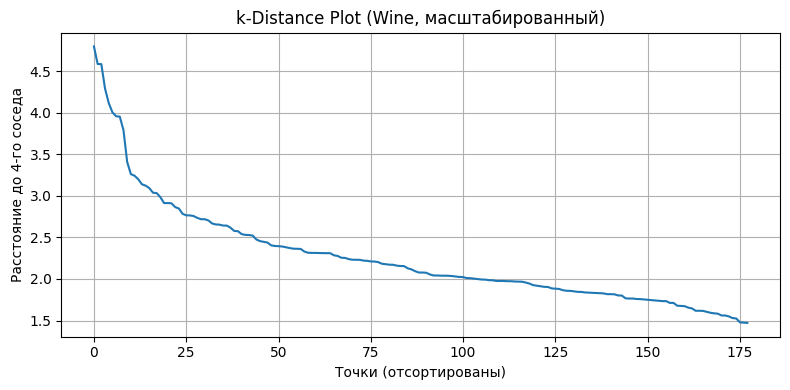

In [9]:
# YOUR CODE HERE
# 1. Масштабируйте X_wine с помощью StandardScaler
# 2. Постройте k-distance plot (k=4)
# 3. Визуально определите «локоть» и запишите подходящее eps =3.1

scaler = StandardScaler()

X_wine_scaled = scaler.fit_transform(X_wine)

k_wine = 4

nbrs = NearestNeighbors(n_neighbors=k_wine).fit(X_wine_scaled)
wine_distances, _ = nbrs.kneighbors(X_wine_scaled)


k_dist_wine = np.sort(wine_distances[:, -1])[::-1] 

plt.figure(figsize=(8, 4))
plt.plot(k_dist_wine)
plt.xlabel("Точки (отсортированы)")
plt.ylabel(f"Расстояние до {k_wine}-го соседа")
plt.title("k-Distance Plot (Wine, масштабированный)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
# YOUR CODE HERE
# 1. Запустите DBSCAN на X_wine_scaled с выбранным eps и min_samples=4
# 2. Выведите: число кластеров, число шумовых точек, долю шума
# 3. Если кластеров > 1, вычислите силуэт (исключив шум) --- число кластеров = 1



eps_wine = 3 # ИЗМЕНИТЕ на основе k-distance plot

wine_db = DBSCAN(eps=eps_wine, min_samples=4)

labels_wine = wine_db.fit_predict(X_wine_scaled)

print("=== Результаты DBSCAN на Wine ===")
print(f"Число кластеров: {len(set(labels_wine)) - (1 if -1 in labels_wine else 0)}")
print(f"число шумовых точек {(labels_wine == -1).sum()}")
print(f"доля шума {(labels_wine == -1).sum()/(labels_wine.size):.4f}")

=== Результаты DBSCAN на Wine ===
Число кластеров: 1
число шумовых точек 11
доля шума 0.0618


---
## Шаг 8. Анализ шумовых точек

Шумовые точки — это объекты, которые DBSCAN не смог отнести ни к одному кластеру. В задаче кластеризации они могут нести важную информацию.

In [11]:
# YOUR CODE HERE
# 1. Выберите строки X_wine, соответствующие шумовым точкам (labels_wine == -1)
# 2. Создайте DataFrame с признаками шумовых точек
# 3. Сравните среднее значение признаков шумовых точек
#    со средним по всей выборке (df_wine.mean())
# 4. Какие признаки у шумовых точек сильно отличаются от среднего? -> proline, proanthocyanins

noise_mask_wine = labels_wine == -1   # маска для шумовых точек
X_wine_noise = X_wine[noise_mask_wine]     # признаки шумовых точек
df_noise = pd.DataFrame(X_wine_noise, columns=df_wine.columns)
df_noise_mean = df_noise.mean()
df_mean = df_wine.mean()
print("=== Средние значения признаков ===")


df = pd.DataFrame({"not_noise" : df_mean, "noise":df_noise_mean})
print(df.describe())
df

=== Средние значения признаков ===
        not_noise       noise
count   13.000000   13.000000
mean    69.133663   63.728951
std    205.400096  180.963760
min      0.361854    0.310000
25%      2.029270    2.086364
50%      2.366517    2.522727
75%     13.000618   12.444545
max    746.893258  656.545455


,not_noise,noise
alcohol,13.000618,12.444545
malic_acid,2.336348,1.989091
ash,2.366517,2.307273
alcalinity_of_ash,19.494944,20.836364
magnesium,99.741573,118.636364
total_phenols,2.295112,2.522727
flavanoids,2.029270,2.086364
nonflavanoid_phenols,0.361854,0.310000
proanthocyanins,1.590899,2.348182
color_intensity,5.058090,4.827273


**❓ Вопрос для размышления:** Чем отличаются шумовые точки от остальных? Являются ли они «плохими» данными или это реальные аномалии?

Cудя по тому, что сущетсвенного отличия средних нет - это реальные аномалии.

---
## Шаг 9. Итоговое сравнение: DBSCAN vs K-Means на Wine

DBSCAN  silhouette: 0.161
K-Means silhouette: 0.285


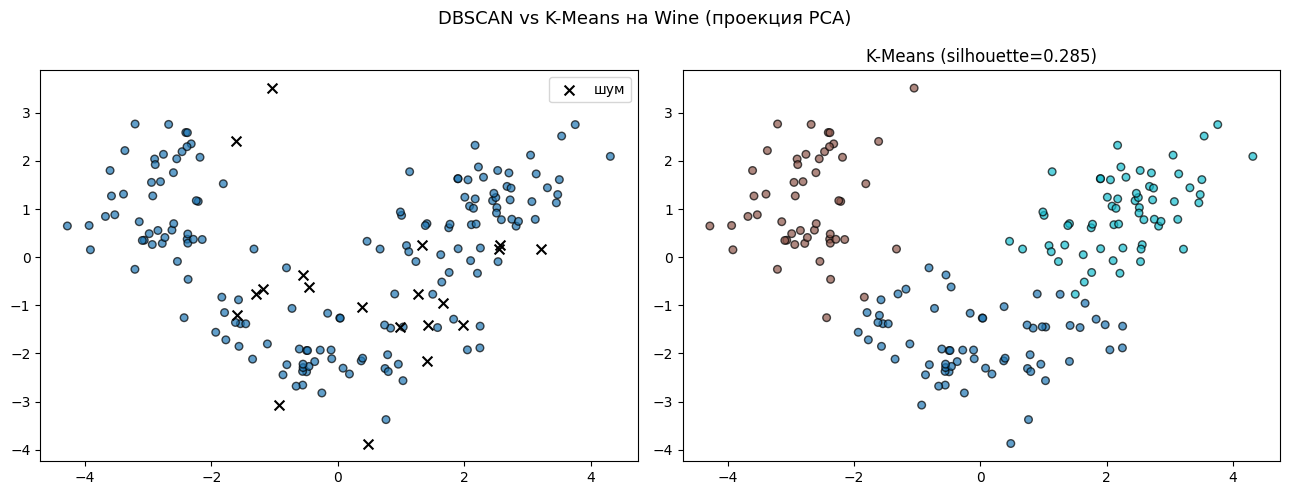

In [12]:
# YOUR CODE HERE
# 1. Обучите KMeans с числом кластеров = числу кластеров DBSCAN
#    (или с n_clusters=3, так как истинных классов 3)
# 2. Вычислите силуэт для K-Means
# 3. Сравните силуэт DBSCAN и K-Means
# 4. Визуализируйте результаты обоих методов в 2D (первые два признака
#    после масштабирования или используйте PCA до 2 компонент)

# Подсказка для PCA:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_2d = pca.fit_transform(X_wine_scaled)

# DBSCAN
db = DBSCAN(eps=2.6, min_samples=4)
db_labels = db.fit_predict(X_wine_scaled)
db_silhouette = silhouette_score(X_wine_scaled, db_labels)

# K-Means
km = KMeans(n_clusters=3, random_state=RANDOM_STATE)
km_labels = km.fit_predict(X_wine_scaled)
km_silhouette = silhouette_score(X_wine_scaled, km_labels)

print(f"DBSCAN  silhouette: {db_silhouette:.3f}")
print(f"K-Means silhouette: {km_silhouette:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mask_noise = db_labels == -1
mask = db_labels != -1
axes[0].scatter(X_wine_2d[mask, 0], X_wine_2d[mask, 1], c=db_labels[mask], cmap='tab10', s=30, edgecolor='k', alpha=0.7)
axes[0].scatter(X_wine_2d[~mask, 0], X_wine_2d[~mask, 1], c='black', marker='x', s=50, label='шум')
axes[0].legend()

axes[1].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1], c=km_labels, cmap='tab10', s=30, edgecolor='k', alpha=0.7)
axes[1].set_title(f"K-Means (silhouette={km_silhouette:.3f})")

plt.suptitle("DBSCAN vs K-Means на Wine (проекция PCA)", fontsize=13)
plt.tight_layout()
plt.show()

---
## Шаг 10. Итоговые выводы

Ответьте на следующие вопросы в ячейке ниже (текст Markdown):

**1. Когда DBSCAN выигрывает у K-Means?**

> 1. Кластеры не шарообразной, выпуклой формы. 2. Когда неизвестно точное число кластеров. 3. Когда нужно отделить шумовые точки.

**2. Когда K-Means предпочтительнее?**

> Кластеры выпуклой шарообразной формы. Известно точное число кластеров. К-means быстрее и интерпретируемее.

**3. Почему масштабирование обязательно для DBSCAN?**

> Потому что алгоритм основан на epsilon окрестностях точек. Без масштабирования расстояния по разным осям будут существенно отличаться.

**4. Как интерпретировать шумовые точки в датасете Wine?**

> Все точки не попавшие ни в один кластер получают метку -1. Они являются шумом.

**5. Можно ли корректно сравнивать силуэт DBSCAN и K-Means напрямую? Почему?**

> Силуэт зависит от k. Если DBSCAN нашёл 5 кластеров, а K-Means 3 - сравниваются разные разбиения, и силуэт несравним напрямую.